# Automatització SARIMA per a 180 sèries setmanals

Aquest notebook automatitza l’ajust i l’avaluació de models SARIMA per a les 180 sèries setmanals definides per grup d’edat, diagnòstic i regió sanitària.

L’objectiu és aplicar un mateix pipeline a totes les sèries i obtenir una taula resum amb els models seleccionats, les mètriques d’error i la cobertura dels intervals de predicció.

In [1]:
import numpy as np
import pandas as pd
from itertools import product
import warnings
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import InterpolationWarning

from sklearn.metrics import mean_absolute_error, mean_squared_error

COLOR_TRAIN = '#1f77b4'   
COLOR_OBS = '#ffbf00'      
COLOR_FORECAST = '#6a0dad' 

df = pd.read_csv("dades_net.csv", sep=",")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["nom_regio", "diagnostic", "edat_bin", "date"]).copy()

## Combinacions de sèries

Es generen totes les combinacions de grup d’edat, diagnòstic i regió sanitària. Cada combinació correspon a una sèrie temporal setmanal.

In [2]:
edats = df["edat_bin"].unique()
diagnostics = df["diagnostic"].unique()
regions = df["nom_regio"].unique()

combinacions = list(product(edats, diagnostics, regions))

print("Total series:", len(combinacions))

Total series: 180


## Construcció de la sèrie

Per a cada combinació es filtra el conjunt de dades, es fixa la freqüència setmanal i es divideix la sèrie en entrenament (2012-2019) i test (2020-2024).

Els valors absents es completen mitjançant interpolació lineal.

In [3]:
def make_series(df, age, diag, region):
    sub = df[
        (df["edat_bin"] == age) &
        (df["diagnostic"] == diag) &
        (df["nom_regio"] == region)
    ].copy()

    s = (
        sub.set_index("date")["taxa_setmanal"]
        .sort_index()
        .asfreq("W-MON")
    )

    return s

def split_series(s):
    train = s[:'2019-12-31'].copy()
    test = s['2020-01-01':].copy()

    train = train.interpolate(method="linear").ffill().bfill()
    test = test.interpolate(method="linear").ffill().bfill()

    return train, test

## Elecció de la diferenciació

L’ordre de diferenciació no estacional es tria automàticament a partir dels tests ADF i KPSS. Si tots dos indiquen estacionarietat, es fixa d = 0; en cas contrari, d = 1.

In [4]:
def choose_d(train):
    x = train.dropna()

    try:
        p_adf = adfuller(x, autolag="AIC")[1]
    except:
        p_adf = np.nan

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", InterpolationWarning)
            p_kpss = kpss(x, regression="c", nlags="auto")[1]
    except:
        p_kpss = np.nan

    if not np.isnan(p_adf) and not np.isnan(p_kpss) and p_adf < 0.05 and p_kpss > 0.05:
        d = 0
    else:
        d = 1

    return d, p_adf, p_kpss

## Cerca SARIMA i validació

Per a cada sèrie es prova una graella SARIMA amb p, q ∈ {0, 1, 2}, P, Q ∈ {0, 1}, D = 1 i m = 52.

Els models s’ordenen segons l’AIC i els tres millors candidats es comparen amb una validació temporal sobre el conjunt d’entrenament. El model final és el que obté menor error mitjà de validació.

In [5]:
def fit_grid(train, d):
    candidates = []

    for p, q, P, Q in product(range(3), range(3), range(2), range(2)):
        order = (p, d, q)
        seasonal_order = (P, 1, Q, 52)

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                model = SARIMAX(
                    train,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )

                res = model.fit(disp=False)

            converged = res.mle_retvals.get("converged", None)

            candidates.append({
                "res": res,
                "order": order,
                "seasonal": seasonal_order,
                "aic": res.aic,
                "converged": converged
            })

        except:
            continue

    if not candidates:
        return None

    candidates = sorted(candidates, key=lambda x: x["aic"])
    return candidates

def rolling_validation_score(series, order, seasonal_order, start_frac=0.7, horizon=26, step=26):
    errors = []
    n = len(series)
    start = max(int(n * start_frac), 104)

    end_train = start

    while end_train + horizon <= n:
        train_cv = series.iloc[:end_train]
        val_cv = series.iloc[end_train:end_train + horizon]

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                model = SARIMAX(
                    train_cv,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                res = model.fit(disp=False)

            pred = res.get_forecast(steps=len(val_cv)).predicted_mean
            err = mean_absolute_error(val_cv, pred)
            errors.append(err)

        except:
            pass

        end_train += step

    if not errors:
        return np.nan

    return np.mean(errors)

In [6]:
def get_coverage(real, low, up):
    mask = ~(real.isna() | low.isna() | up.isna())

    if mask.sum() == 0:
        return np.nan

    real = real[mask]
    low = low[mask]
    up = up[mask]

    return ((real >= low) & (real <= up)).mean()


def get_metrics(res, test):
    fc = res.get_forecast(steps=len(test))

    pred = fc.predicted_mean
    conf = fc.conf_int()

    low = conf.iloc[:, 0]
    up = conf.iloc[:, 1]

    mae = mean_absolute_error(test, pred)
    rmse = np.sqrt(mean_squared_error(test, pred))

    cov_total = get_coverage(test, low, up)

    covid_mask = (test.index >= "2020-01-01") & (test.index <= "2021-12-31")
    post_mask = test.index >= "2022-01-01"

    if covid_mask.sum() > 0:
        cov_covid = get_coverage(test[covid_mask], low[covid_mask], up[covid_mask])
    else:
        cov_covid = np.nan

    if post_mask.sum() > 0:
        cov_post = get_coverage(test[post_mask], low[post_mask], up[post_mask])
    else:
        cov_post = np.nan

    return pred, low, up, mae, rmse, cov_total, cov_covid, cov_post
    
    
def check_res(res, lags=10):
    e = res.resid.dropna()

    burn = max(res.loglikelihood_burn, res.filter_results.nobs_diffuse)
    e = e.iloc[burn:]

    if len(e) <= lags:
        return np.nan

    out = acorr_ljungbox(e, lags=[lags], return_df=True)
    return out["lb_pvalue"].iloc[0]

def plot_pred(test, pred, low=None, up=None, title=""):
    plt.figure(figsize=(12, 5))
    plt.plot(test.index, test.values, label="valors observats", color=COLOR_OBS, linewidth=1.5)
    plt.plot(pred.index, pred.values, label="predicció SARIMA", color=COLOR_FORECAST, linewidth=1.5)

    if low is not None and up is not None:
        plt.fill_between(
            pred.index,
            low.values,
            up.values,
            color=COLOR_FORECAST,
            alpha=0.1
        )

    plt.title(title)
    plt.legend()
    plt.show()


In [7]:
def run_one(df, age, diag, region):
    s = make_series(df, age, diag, region)
    train, test = split_series(s)

    if len(train) == 0 or len(test) == 0:
        row = {
            "age": age,
            "diag": diag,
            "region": region,
            "status": "fail",
            "error": "empty train or test"
        }
        return row, None, None

    d, p_adf, p_kpss = choose_d(train)

    candidates = fit_grid(train, d)

    if candidates is None:
        row = {
            "age": age,
            "diag": diag,
            "region": region,
            "status": "fail",
            "error": "no model fitted"
        }
        return row, None, None

    top_candidates = candidates[:3]

    for cand in top_candidates:
        cand["cv_mae"] = rolling_validation_score(
            train,
            cand["order"],
            cand["seasonal"]
        )

    top_candidates = sorted(
        top_candidates,
        key=lambda x: np.inf if pd.isna(x["cv_mae"]) else x["cv_mae"]
    )

    best = top_candidates[0]

    res = best["res"]
    order = best["order"]
    seasonal = best["seasonal"]
    aic = best["aic"]
    converged = best["converged"]
    cv_mae = best["cv_mae"]

    pred, low, up, mae, rmse, cov_total, cov_covid, cov_post = get_metrics(res, test)
    lb_p = check_res(res)

    row = {
        "age": age,
        "diag": diag,
        "region": region,
        "p_adf": p_adf,
        "p_kpss": p_kpss,
        "d": int(d),
        "order": str(order),
        "seasonal": str(seasonal),
        "aic": float(aic),
        "cv_mae": float(cv_mae) if pd.notna(cv_mae) else np.nan,
        "converged": converged,
        "mae_test": float(mae),
        "rmse_test": float(rmse),
        "cov_total": float(cov_total) if pd.notna(cov_total) else np.nan,
        "cov_covid": float(cov_covid) if pd.notna(cov_covid) else np.nan,
        "cov_post": float(cov_post) if pd.notna(cov_post) else np.nan,
        "lb_p": float(lb_p) if pd.notna(lb_p) else np.nan,
        "status": "ok",
        "error": None
    }

    pred_df = pd.DataFrame({
        "date": test.index,
        "real": test.values,
        "pred": pred.values,
        "low": low.values,
        "up": up.values,
        "age": age,
        "diag": diag,
        "region": region
    })

    plot_data = {
        "train": train,
        "test": test,
        "pred": pred,
        "low": low,
        "up": up
    }

    return row, pred_df, plot_data

## Exemple visual

Abans d’executar l’automatització completa, es comprova el pipeline amb una sèrie concreta. El gràfic mostra només el període de test, la predicció i l’interval de predicció.

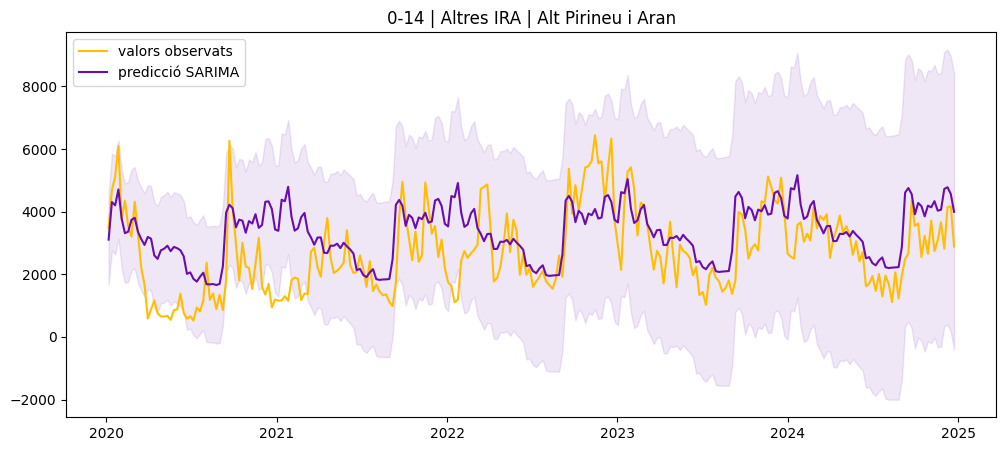

In [8]:
row, pred_df, plot_data = run_one(df, "0-14", "Altres IRA", "Alt Pirineu i Aran")

plot_pred(
    plot_data["test"],
    plot_data["pred"],
    plot_data["low"],
    plot_data["up"],
    title="0-14 | Altres IRA | Alt Pirineu i Aran"
)

## Automatització completa

S’aplica el pipeline a les 180 sèries i es guarden tant els resultats resum com les prediccions setmanals del període de test.

In [9]:
rows = []
preds = []

for i, (age, diag, region) in enumerate(combinacions, start=1):    
    print(f"{i}/180 - {age} | {diag} | {region}")
    try:
        row, pred_df, _ = run_one(df, age, diag, region)
        rows.append(row)

        if pred_df is not None:
            preds.append(pred_df)

    except Exception as e:
        rows.append({
            "age": age,
            "diag": diag,
            "region": region,
            "status": "fail",
            "error": str(e)
        })

1/180 - 0-14 | Altres IRA | Alt Pirineu i Aran
2/180 - 0-14 | Altres IRA | Barcelona Ciutat
3/180 - 0-14 | Altres IRA | Barcelona Metropolitana Nord
4/180 - 0-14 | Altres IRA | Barcelona Metropolitana Sud
5/180 - 0-14 | Altres IRA | Camp de Tarragona
6/180 - 0-14 | Altres IRA | Catalunya Central
7/180 - 0-14 | Altres IRA | Girona
8/180 - 0-14 | Altres IRA | Lleida
9/180 - 0-14 | Altres IRA | PenedÃ¨s
10/180 - 0-14 | Altres IRA | Terres de l'Ebre
11/180 - 0-14 | Bronquiolitis | Alt Pirineu i Aran
12/180 - 0-14 | Bronquiolitis | Barcelona Ciutat
13/180 - 0-14 | Bronquiolitis | Barcelona Metropolitana Nord
14/180 - 0-14 | Bronquiolitis | Barcelona Metropolitana Sud
15/180 - 0-14 | Bronquiolitis | Camp de Tarragona
16/180 - 0-14 | Bronquiolitis | Catalunya Central
17/180 - 0-14 | Bronquiolitis | Girona
18/180 - 0-14 | Bronquiolitis | Lleida
19/180 - 0-14 | Bronquiolitis | PenedÃ¨s
20/180 - 0-14 | Bronquiolitis | Terres de l'Ebre
21/180 - 0-14 | COVID-19 | Alt Pirineu i Aran
22/180 - 0-14 |

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:2182: RuntimeWarning: invalid value encountered in scalar divide
  s_hat = s1 / s0


28/180 - 0-14 | COVID-19 | Lleida


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:2182: RuntimeWarning: invalid value encountered in scalar divide
  s_hat = s1 / s0


29/180 - 0-14 | COVID-19 | PenedÃ¨s


...

112/180 - 15+ | COVID-19 | Barcelona Ciutat
113/180 - 15+ | COVID-19 | Barcelona Metropolitana Nord
114/180 - 15+ | COVID-19 | Barcelona Metropolitana Sud
115/180 - 15+ | COVID-19 | Camp de Tarragona
116/180 - 15+ | COVID-19 | Catalunya Central


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:2182: RuntimeWarning: invalid value encountered in scalar divide
  s_hat = s1 / s0


117/180 - 15+ | COVID-19 | Girona
118/180 - 15+ | COVID-19 | Lleida
119/180 - 15+ | COVID-19 | PenedÃ¨s
120/180 - 15+ | COVID-19 | Terres de l'Ebre


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:2182: RuntimeWarning: invalid value encountered in scalar divide
  s_hat = s1 / s0


121/180 - 15+ | Escarlatina | Alt Pirineu i Aran
122/180 - 15+ | Escarlatina | Barcelona Ciutat
123/180 - 15+ | Escarlatina | Barcelona Metropolitana Nord
124/180 - 15+ | Escarlatina | Barcelona Metropolitana Sud
125/180 - 15+ | Escarlatina | Camp de Tarragona
126/180 - 15+ | Escarlatina | Catalunya Central
127/180 - 15+ | Escarlatina | Girona
128/180 - 15+ | Escarlatina | Lleida
129/180 - 15+ | Escarlatina | PenedÃ¨s
130/180 - 15+ | Escarlatina | Terres de l'Ebre
131/180 - 15+ | Faringoamigdalitis | Alt Pirineu i Aran
132/180 - 15+ | Faringoamigdalitis | Barcelona Ciutat
133/180 - 15+ | Faringoamigdalitis | Barcelona Metropolitana Nord
134/180 - 15+ | Faringoamigdalitis | Barcelona Metropolitana Sud
135/180 - 15+ | Faringoamigdalitis | Camp de Tarragona
136/180 - 15+ | Faringoamigdalitis | Catalunya Central
137/180 - 15+ | Faringoamigdalitis | Girona
138/180 - 15+ | Faringoamigdalitis | Lleida
139/180 - 15+ | Faringoamigdalitis | PenedÃ¨s
140/180 - 15+ | Faringoamigdalitis | Terres de

## Fitxers de sortida

Es desen dos fitxers: `results_sarima.csv`, amb el resum de models i mètriques, i `preds_sarima.csv`, amb les prediccions setmanals.

In [10]:
results = pd.DataFrame(rows)
results.to_csv("results_sarima.csv", index=False)

if len(preds) > 0:
    preds_df = pd.concat(preds, ignore_index=True)
    preds_df.to_csv("preds_sarima.csv", index=False)

print("Files saved:")
print("- results_sarima.csv")
print("- preds_sarima.csv")

Files saved:
- results_sarima.csv
- preds_sarima.csv


## Comprovació final

Es revisa el nombre de sèries ajustades correctament i, si escau, les combinacions que no s’han pogut modelitzar.

In [12]:
results = pd.read_csv("results_sarima.csv")
results["status"].value_counts()

status
ok      174
fail      6
Name: count, dtype: int64

In [13]:
results[results["status"] == "fail"][["age", "diag", "region", "error"]].head(20)

,age,diag,region,error
20,0-14,COVID-19,Alt Pirineu i Aran,empty train or test
22,0-14,COVID-19,Barcelona Metropolitana Nord,empty train or test
23,0-14,COVID-19,Barcelona Metropolitana Sud,empty train or test
24,0-14,COVID-19,Camp de Tarragona,empty train or test
25,0-14,COVID-19,Catalunya Central,empty train or test
29,0-14,COVID-19,Terres de l'Ebre,empty train or test
